# Storytelling Application using Hugging Face Pipelines
**ISOM5240 Assignment** — Image → Caption → Story → Audio  
Application for 3–10 year-old kids

In [ ]:
!pip install "transformers<5.0.0" torch pillow

In [20]:
# Imports
import os
import numpy as np
from transformers import pipeline
from PIL import Image
from IPython.display import display, Audio

In [22]:
# function part

# img2text
def img2text(url):
    # Newer transformers: task is "image-text-to-text" (replaces "image-to-text")
    image_to_text_model = pipeline("image-text-to-text", model="Salesforce/blip-image-captioning-base")
    result = image_to_text_model(url)
    # Output is list of dicts; use "generated_text" (or "generated_token_ids" in some versions)
    out = result[0] if result else {}
    text = out.get("generated_text") or out.get("generated_token_ids")
    if text is None:
        text = str(out)
    elif not isinstance(text, str):
        from transformers import AutoProcessor
        text = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base").decode(text, skip_special_tokens=True)
    return text

# text2story
def text2story(text):
    # Limit length at generation: ~100 words ≈ 130 tokens (English ~1.3 tokens/word)
    max_tokens = 130
    pipe = pipeline("text-generation", model="pranavpsv/genre-story-generator-v2")
    story_text = pipe(text, max_new_tokens=max_tokens)[0]["generated_text"]
    words = story_text.split()
    if len(words) > 100:
        # Fallback: truncate at last complete sentence within 100 words
        first_100 = " ".join(words[:100])
        last_sentence_end = max(first_100.rfind("."), first_100.rfind("!"), first_100.rfind("?"))
        if last_sentence_end >= 0:
            story_text = first_100[: last_sentence_end + 1].strip()
        else:
            story_text = first_100
    return story_text

# text2audio
def text2audio(story_text):
    pipe = pipeline("text-to-speech", model="Matthijs/mms-tts-eng")
    audio_data = pipe(story_text)
    return audio_data

Enter the path of the image (e.g. filename if in current folder): /content/test_kids_playing.jpg
image_path = /content/test_kids_playing.jpg


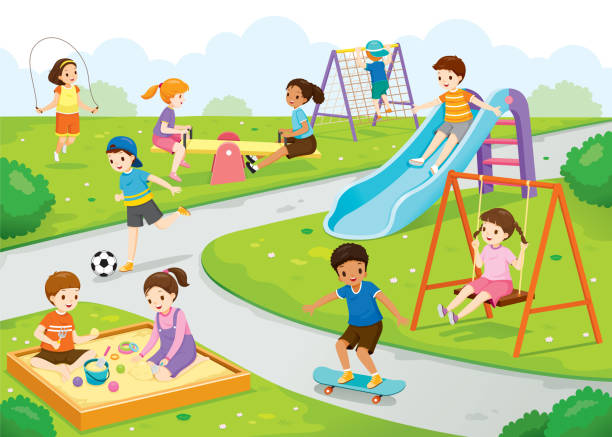

In [23]:
# main part
# Image Input
# Allow input of the image path (e.g. after uploading the image to the Colab folder).
image_path = input("Enter the path of the image (e.g. filename if in current folder): ").strip()
print("image_path =", image_path)

# Verify the file exists; if so, display the image
if os.path.isfile(image_path):
    img = Image.open(image_path).convert("RGB")
    display(img)
else:
    print("Error: File not found. Please check the path and run this cell again.")

In [24]:
# Step 1: Image to text (caption)
scenario = img2text(image_path)
print("Caption:", scenario)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

TypeError: BatchEncoding.to() got an unexpected keyword argument 'dtype'